In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

files = sorted(glob.glob("*_attentional_spotter_results.csv"))
all_players = []
for file in files:
    df = pd.read_csv(file)
    # Keep only completed trials
    df_completed = df[df["Completed"] == True]
    # Compute mean RT per level
    level_means = ( df_completed.groupby("Level")["InitialResponseTime(ms)"].mean() )
    # Ensure all 15 levels exist (fill missing levels with NaN)
    level_means = level_means.reindex(range(1,16))
    all_players.append(level_means.values) # Convert to 21 × 15 matrix

data_matrix = np.array(all_players)

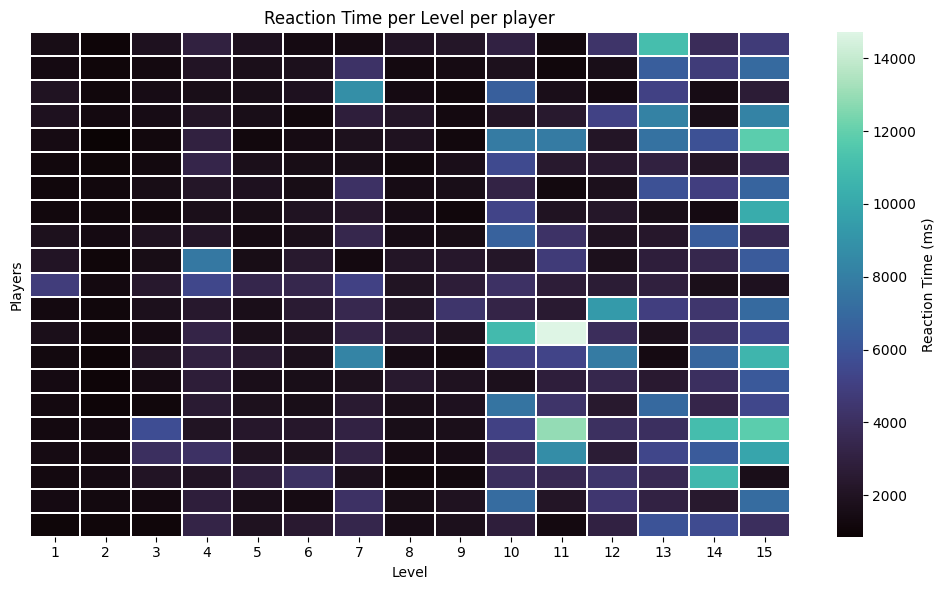

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))

sns.heatmap(
    data_matrix,
    cmap="mako",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={'label': 'Reaction Time (ms)'},
    xticklabels=range(1,16),
    yticklabels=False
)

plt.xlabel("Level")
plt.ylabel("Players")
plt.title("Reaction Time per Level per player")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

desc_stats = pd.DataFrame({
    "Mean_RT": np.nanmean(data_matrix, axis=0),
    "SD_RT": np.nanstd(data_matrix, axis=0)
}, index=range(1,16))

desc_stats

,Mean_RT,SD_RT
1,1620.619048,761.761710
2,1157.119048,141.234178
3,1869.730159,1057.011764
4,2972.746032,1347.401174
5,1876.047619,492.844849
6,1995.190476,682.467764
7,3418.047619,1930.614520
8,1732.904762,385.101212
9,1801.023810,686.708860
10,4733.809524,2311.934742


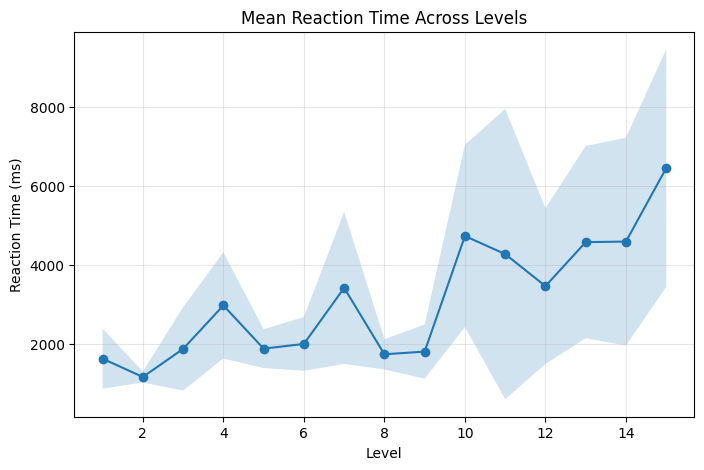

In [ ]:
mean_rt = np.nanmean(data_matrix, axis=0)
sd_rt = np.nanstd(data_matrix, axis=0)
levels = range(1,16)

plt.figure(figsize=(8,5))

plt.plot(levels, mean_rt, marker='o')
plt.fill_between(levels,
                 mean_rt - sd_rt,
                 mean_rt + sd_rt,
                 alpha=0.2)

plt.xlabel("Level")
plt.ylabel("Reaction Time (ms)")
plt.title("Mean Reaction Time Across Levels")
plt.grid(alpha=0.3)
plt.show()

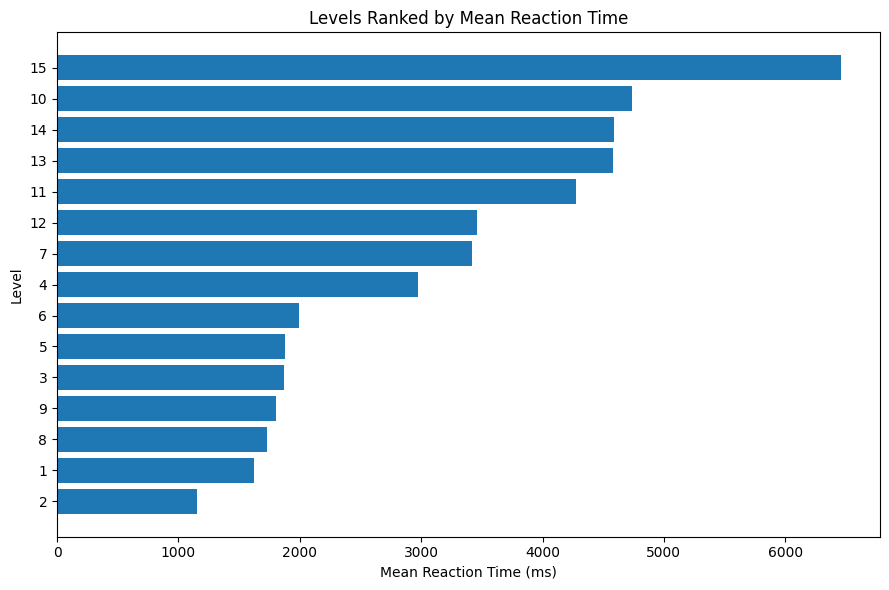

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Compute means
level_means = np.nanmean(data_matrix, axis=0)

# Sort from lowest to highest
sorted_idx = np.argsort(level_means)
sorted_levels = np.array(range(1,16))[sorted_idx]
sorted_means = level_means[sorted_idx]

plt.figure(figsize=(9,6))

plt.barh(sorted_levels.astype(str), sorted_means)

plt.xlabel("Mean Reaction Time (ms)")
plt.ylabel("Level")
plt.title("Levels Ranked by Mean Reaction Time")

plt.tight_layout()
plt.show()

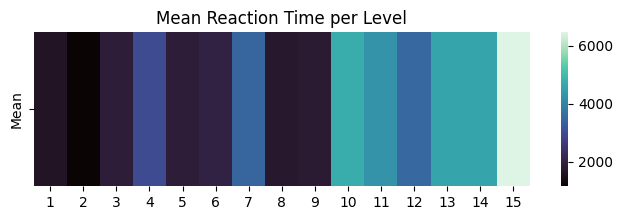

In [ ]:
plt.figure(figsize=(8,2))
sns.heatmap(mean_rt.reshape(1,-1),
            cmap="mako",
            xticklabels=range(1,16),
            yticklabels=["Mean"])
plt.title("Mean Reaction Time per Level")
plt.show()

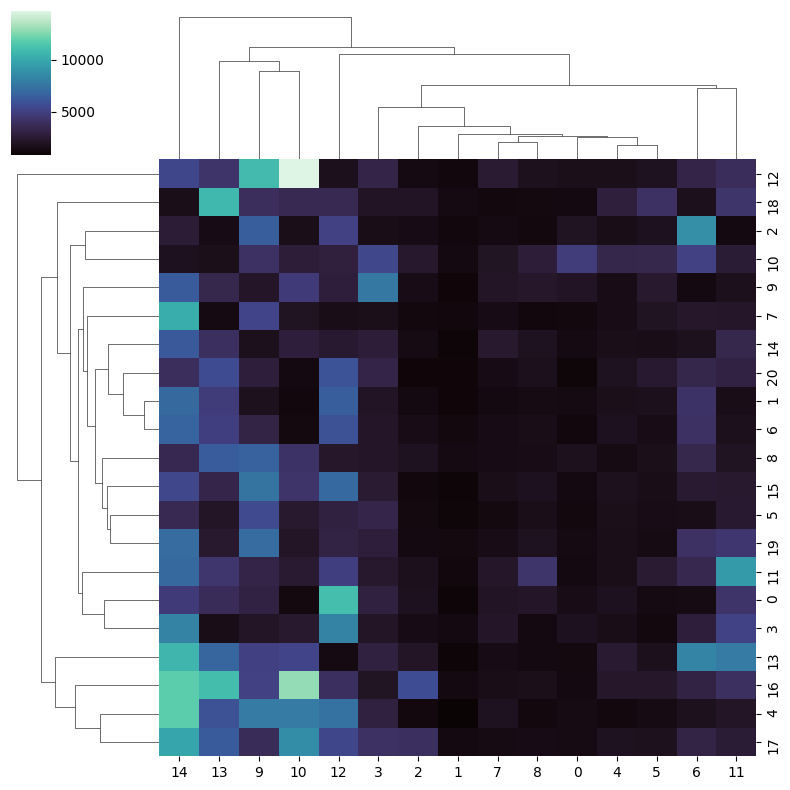

In [ ]:
sns.clustermap(data_matrix,
               cmap="mako",
               figsize=(8,8))

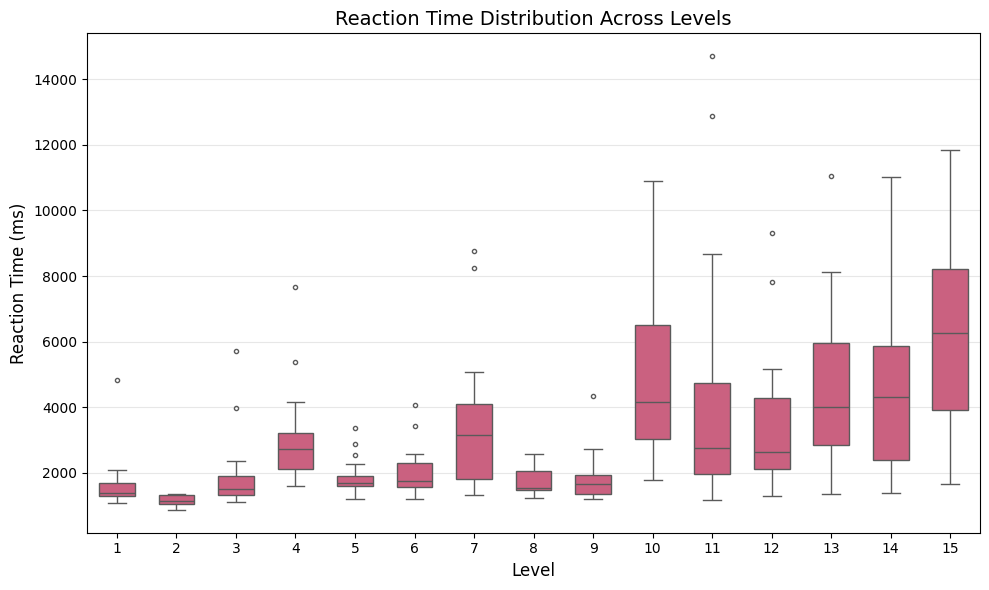

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert to long format for seaborn
import pandas as pd
df_long = pd.DataFrame(data_matrix)
df_long = df_long.melt(var_name="Level", value_name="RT")
df_long["Level"] += 1

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_long,
    x="Level",
    y="RT",
    width=0.6,
    color="#DB5079",
    fliersize=3,
    linewidth=1
)

plt.xlabel("Level", fontsize=12)
plt.ylabel("Reaction Time (ms)", fontsize=12)
plt.title("Reaction Time Distribution Across Levels", fontsize=14)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

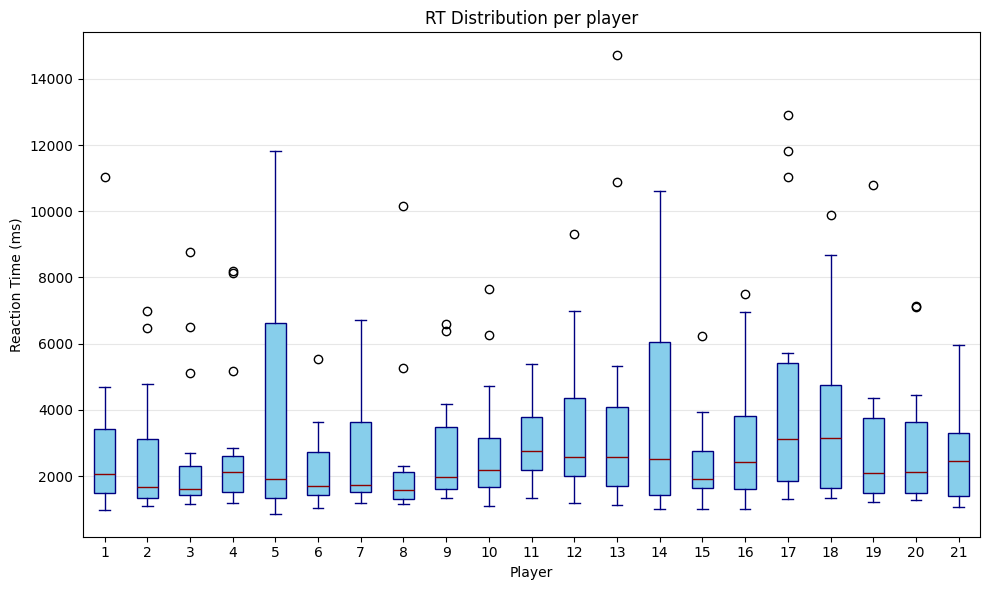

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(
    data_matrix.T,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue', color='navy'),
    medianprops=dict(color='darkred'),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy')
)

plt.xlabel("Player")
plt.ylabel("Reaction Time (ms)")
plt.title("RT Distribution per player")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

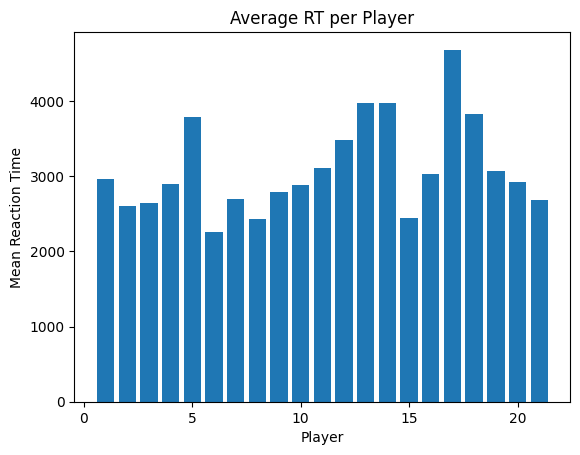

In [ ]:
player_means = np.nanmean(data_matrix, axis=1)

plt.figure()
plt.bar(range(1, len(player_means)+1), player_means)
plt.xlabel("Player")
plt.ylabel("Mean Reaction Time")
plt.title("Average RT per Player")
plt.show()

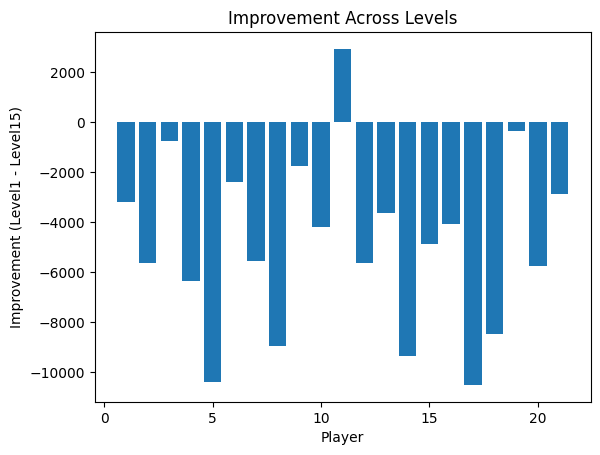

In [ ]:
improvement = data_matrix[:,0] - data_matrix[:,-1]

plt.figure()
plt.bar(range(1, len(improvement)+1), improvement)
plt.xlabel("Player")
plt.ylabel("Improvement (Level1 - Level15)")
plt.title("Improvement Across Levels")
plt.show()

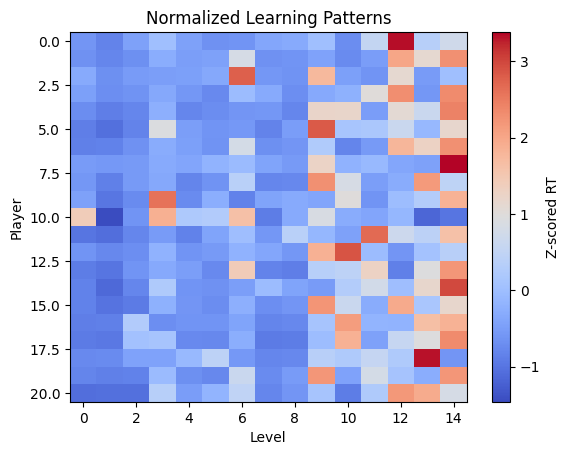

In [ ]:
z_matrix = (data_matrix - np.nanmean(data_matrix, axis=1, keepdims=True)) / \
           np.nanstd(data_matrix, axis=1, keepdims=True)

plt.figure()
plt.imshow(z_matrix, aspect='auto', cmap='coolwarm')
plt.colorbar(label="Z-scored RT")
plt.xlabel("Level")
plt.ylabel("Player")
plt.title("Normalized Learning Patterns")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

desc_level = pd.DataFrame({
    "Mean": np.nanmean(data_matrix, axis=0),
    "Median": np.nanmedian(data_matrix, axis=0),
    "SD": np.nanstd(data_matrix, axis=0),
    "Min": np.nanmin(data_matrix, axis=0),
    "Max": np.nanmax(data_matrix, axis=0)
}, index=range(1,16))

desc_level

,Mean,Median,SD,Min,Max
1,1620.619048,1372.0,761.761710,1076.0,4822.0
2,1157.119048,1152.0,141.234178,864.0,1352.0
3,1869.730159,1504.0,1057.011764,1110.0,5715.0
4,2972.746032,2731.0,1347.401174,1588.0,7664.0
5,1876.047619,1685.0,492.844849,1205.0,3366.0
6,1995.190476,1753.0,682.467764,1189.0,4080.0
7,3418.047619,3142.0,1930.614520,1330.0,8763.0
8,1732.904762,1535.0,385.101212,1226.0,2578.0
9,1801.023810,1668.0,686.708860,1185.0,4334.0
10,4733.809524,4155.0,2311.934742,1777.0,10896.0


In [ ]:
desc_player = pd.DataFrame({
    "Mean": np.nanmean(data_matrix, axis=1),
    "SD": np.nanstd(data_matrix, axis=1),
    "Median":np.nanmedian(data_matrix, axis=1),
    "Min": np.nanmin(data_matrix, axis=1),
    "Max": np.nanmax(data_matrix, axis=1)
}, index=range(1,22))

desc_player

,Mean,SD,Median,Min,Max
1,2967.600000,2426.827993,2069.0,984.0,11048.0
2,2604.333333,1924.919173,1685.0,1094.0,6993.0
3,2649.333333,2206.176562,1608.0,1152.0,8763.0
4,2900.133333,2268.059490,2114.0,1189.0,8210.0
5,3793.866667,3314.016734,1900.0,864.0,11831.0
6,2257.933333,1166.644846,1702.0,1035.0,5542.0
7,2696.933333,1775.562839,1735.0,1176.0,6726.0
8,2426.733333,2290.496612,1571.0,1155.0,10172.0
9,2791.200000,1667.072252,1982.0,1352.0,6598.0
10,2887.466667,1840.156691,2179.0,1096.0,7664.0


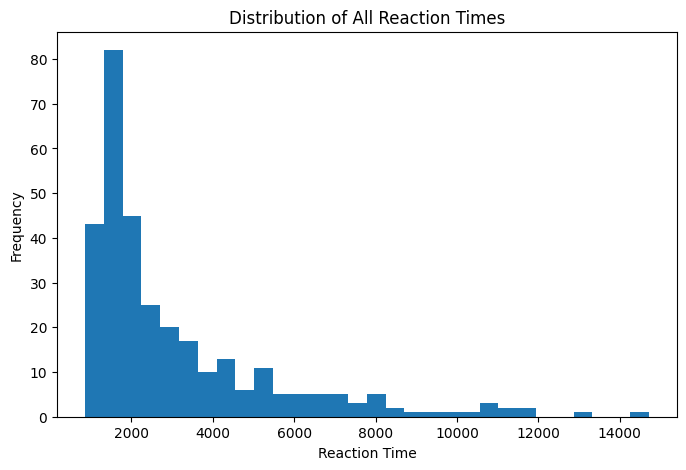

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(data_matrix.flatten(), bins=30)
plt.xlabel("Reaction Time")
plt.ylabel("Frequency")
plt.title("Distribution of All Reaction Times")
plt.show()

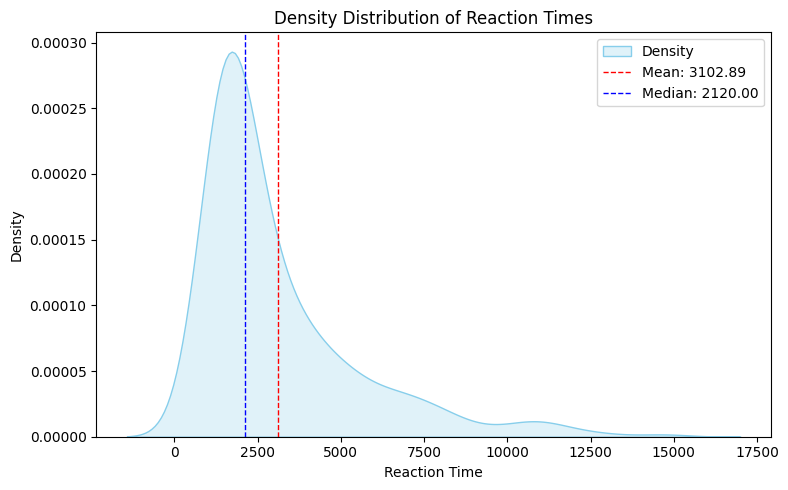

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assuming data_matrix is already defined; flattening for analysis
data_flat = data_matrix.flatten()

# 1. Calculate Statistics
mean_val = np.mean(data_flat)
median_val = np.median(data_flat)

# 2. Plotting
plt.figure(figsize=(8,5))
sns.kdeplot(data_flat, fill=True, color="skyblue", label="Density")

# 3. Add Mean Line
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1,
            label=f'Mean: {mean_val:.2f}')

plt.axvline(median_val, color='blue', linestyle='--', linewidth=1,
            label=f'Median: {median_val:.2f}')

plt.xlabel("Reaction Time")
plt.ylabel("Density")
plt.title("Density Distribution of Reaction Times")
plt.legend()
plt.tight_layout()

# Save or show the plot
plt.savefig('reaction_time_dist.png')
plt.show()

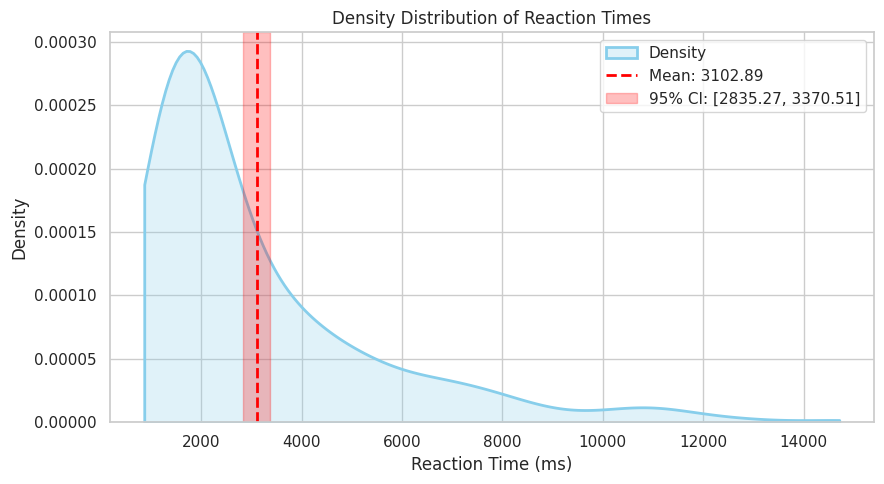

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Clean style
sns.set_theme(style="whitegrid")

# Flatten and remove NaNs
data_flat = data_matrix.flatten()
data_flat = data_flat[~np.isnan(data_flat)]

# 1. Calculate statistics
mean_val = np.mean(data_flat)

# 95% CI for the mean
ci_low, ci_high = stats.t.interval(
    0.95,
    df=len(data_flat)-1,
    loc=mean_val,
    scale=stats.sem(data_flat)
)

# 2. Plot density
plt.figure(figsize=(9,5))

sns.kdeplot(
    data_flat,
    fill=True,
    color="skyblue",
    linewidth=2,
    cut=0,
    label="Density"
)

# 3. Mean line
plt.axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_val:.2f}"
)

# 4. Confidence interval shading
plt.axvspan(
    ci_low,
    ci_high,
    alpha=0.25,
    color="red",
    label=f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
)

plt.xlabel("Reaction Time (ms)")
plt.ylabel("Density")
plt.title("Density Distribution of Reaction Times")

plt.legend()
plt.tight_layout()

plt.savefig("reaction_time_distribution.png", dpi=300)
plt.show()

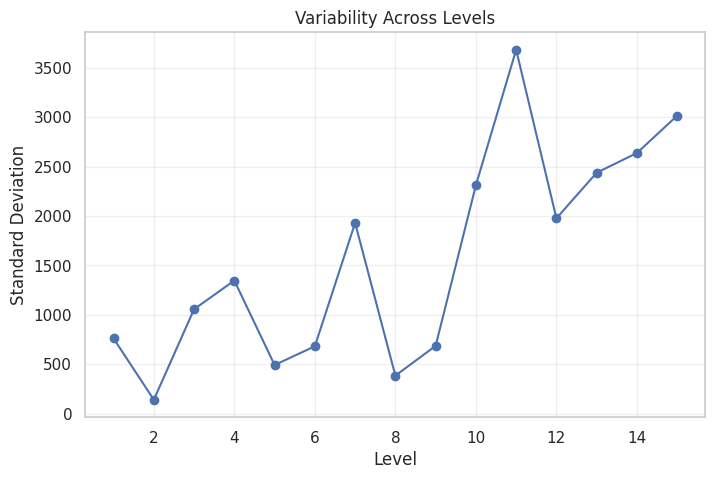

In [ ]:
sd_levels = np.nanstd(data_matrix, axis=0)

plt.figure(figsize=(8,5))
plt.plot(range(1,16), sd_levels, marker='o')
plt.xlabel("Level")
plt.ylabel("Standard Deviation")
plt.title("Variability Across Levels")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from scipy.stats import pearsonr

levels = np.arange(1,16)
mean_rt = np.nanmean(data_matrix, axis=0)

r, p = pearsonr(levels, mean_rt)
r, p

(np.float64(0.8337214000199256), np.float64(0.00011238971121326509))